# Statistical Machine Translation Tutorial (Intro)
Ye Kyaw Thu, Lab Leader, Language Understanding Lab., Myanmar  
For AI Fundamental Class students  
Date: 26 April 2026  

ဒီ Notebook က Github က MTRSS (Machine Translation Research Summer School) က code တွေကို ဆာဗာတစ်ခုပေါ်ကို ဒေါင်းလုဒ်လုပ်ပြီး အတန်းထဲမှာ ပထမဆုံး run ပြခဲ့တာမို့ error သုံးခု တက်တာကိုလည်း လက်တွေ့ရှင်းရင်းနဲ့ run ခဲ့တဲ့ notebook ပါ။  

- ပထမ error က ထုံးစံအတိုင်းပဲ perl script တွေ၊ configuration file မှာ ကိုယ့်စက်ရဲ့ path တွေကို ဖြည့်တဲ့အခါမှာ ကျန်ခဲ့တာမျိုးပါ
- ဒုတိယ error က GIZA++ နဲ့ ပတ်သက်ပြီး ဖြစ်တဲ့ error ပါ။ GIZA++ install လုပ်ထားတဲ့ path (/home/ye/tool/giza-pp/GIZA++-v2) အောက်မှာ mklcls ဖိုင်ကိုပါ ကော်ပီကူးထည့်လိုက်ရင် ပြေလည်းပါတယ်။   
- တတိယ error ကတော့ SGM အတွက် ဆောက်ထားတဲ့ ဖိုလ်ဒါနာမည်ကို စကားပြောရင်း၊ စာသင်ရင်းနဲ့ ရိုက်လိုက်တာမို့ test-gen ဆိုပြီး မှာရိုက်လိုက်လို့ SMT run တဲ့အခါမှာ တက်တဲ့ error ပါ။ အမှန်က test-sgm ဖြစ်ရပါမယ်။ :P

## Data

In [1]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial'

In [2]:
!ls ./data/*

./data/dev.my  ./data/test.my  ./data/train.my
./data/dev.th  ./data/test.th  ./data/train.th


## Data Size

for training:  

In [4]:
!wc ./data/train.*

   62625   734742  7067941 ./data/train.my
   62625   439436  5110712 ./data/train.th
  125250  1174178 12178653 total


for development or validation:  

In [5]:
!wc ./data/dev.*

  10000  117884 1133121 ./data/dev.my
  10000   71013  825957 ./data/dev.th
  20000  188897 1959078 total


for testing:  

In [6]:
!wc ./data/test.*

   8000   93919  901455 ./data/test.my
   8000   56113  651909 ./data/test.th
  16000  150032 1553364 total


Let's see data format:  

In [7]:
!head ./data/train.th

คือ มี อาการ อย่าง ใด อย่าง หนึ่ง ต่อ ไป นี้
ใจเย็น ๆ ก่อน นะ คะ
ไม่ มี โรค ประจำ ตัว
อาการ เบื้อง ต้น
แล้ว เอา หู ฟัง วาง ตรงเหนือ ข้อ พับ ตรง นี้ นิด นึง นะ คะ
ผม กิน ไอ พวก กุ้ง
แต่ว่า
ผม ควร ประคบ น้ำ แข็ง บน หัว ไหม
เดี๋ยว รบกวน ไป ตรวจรังสี คอมพิวเตอร์ นิด นึง นะ ครับ
ระหว่าง นี้ นั่ง รอ ตรง นั้น ก่อน นะ ครับ


In [8]:
!head ./data/train.my

အောက် ပါ ရော ဂါ လက္ခ ဏာ တွေ များ ရှိ ရင်
စိတ် ကို အေး အေး ဆေး ဆေး ထား ပါ
နာ တာ ရှည် ရော ဂါ ရယ် လို့ မ ရှိ ပါ ဘူး ဗျ
လက္ခ ဏာ တွေ နဲ့
ပြီး တဲ့ အ ခါ နား ကြပ် ကို တံ တော င့် ဆစ် နား မှာ ထား မှာ မို့ ပါ ရှင်
ပု စွန် တော့ ကျွန် တော် စား တယ် 
သို့ ပေ မဲ့ လည်း
ကျွန် တော် ခေါင်း ပေါ် ရေ ခဲ တင် ထား ရ မ လား 
ကွန် ပြူ တာ ရောင် ခြည် နဲ့ ထပ် စစ် ဆေး ပါ မယ် နော်
ဒီ ကြား မှာ ခ ဏ လေး ထိုင် စော င့် ပေး လို့ ရ မ လား


In [9]:
!head ./data/dev.th

เกิด ตั้งแต่ เมื่อ ไร
ฉัน รู้สึก หายใจ ไม่ อิ่ม หลัง อาหาร แต่ละ มื้อ
ระบบ การ ป้องกัน การ เกิด ภัย ซ้ำ
มีด หัน ปลา
เจ็บ คอ
โดน บริเวณ ไหน คะ
เดี๋ยว ดู วีดีโอ สอน แปรง ฟัน อัน นี้ นะ ครับ
กระพริบ ตา
คิด ว่า หลัง ผ่า ตอน นี้ น่า จะ เจ็บ กว่า ค่ะ
ต่อ ไป หมอ จะ ตรวจ ภาย ใน นะ คะ


In [10]:
!head ./data/dev.my

ဒီ လို မျိုး ဘယ် ချိန် က စ ဖြစ် တာ လဲ 
အ စာ စား ပြီး တိုင်း အ သက် ရှူ ရင် မ ဝ သ လို ခံ စား ရ တယ် 
ဒီ လို အ ဖြစ် အ ပျက် မျိုး ထပ် မ ကြုံ ရ အောင် ပေါ့ 
ငါး လှီး တဲ့ ဓါး 
လည် ချောင်း လည်း နာ ကျင် တယ် ရှင် 
ဘယ် နား ကိုက် သွား တာ လဲ ရှင့် 
တစ် အော င့် နေ သွား တိုက် တာ သင် တဲ့ ဗီ ဒီ ယို ကို ကြ ည့် ပါ ခင် ဗျာ့
မျက် လုံး မှိတ် ပြ ပါ 
ခွဲ စိတ် လို့ ပြီး သွား ရင် ပို မို နာ ကျင် နိုင် လိ မ့် မယ် 
ဆ ရာ မ အ တွင်း ဘက် ကို တ ဆက် ထဲ စမ်း သပ် မယ် ရှင် 


In [11]:
!head ./data/test.th

ต้อง ผ่าตัด ไหม
หนัง ตา กระตุก
คุณ ควร งด แอลกอฮอล์ และ รับประทาน อาหาร ที่ มี ประโยชน์ ซึ่ง อุดม ไป ด้วย โปรตีน และ วิตามิน
เธอ ป่วย ค่ะ และ เธอ ไม่ ได้ กัก ตัว ค่ะ
น้องทาน ยา ครั้ง สุดท้าย เมื่อ ไหร่ คะ
แนวโน้ม ที่ ร่างกาย ติด เชื้อ บาดเจ็บ ต่อ สมอง
เรียก ญาติ คุณปราโมท เข้า มา ให้ หน่อย ค่ะ
ลด ปริมาน ของ หวาน มัน
ยัง คิด ว่า พวก เขา ยัง อยู่ ด้วย กัน กับ ผม
หลัง จาก รับ ยา แล้ว กลับ บ้าน ได้ เลย นะ ครับ


In [12]:
!head ./data/test.my

ခွဲ မှ ရ မှာ လား 
မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ် 
အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည် 
ဟုတ် ကဲ့  သူ ဖျား ပါ တယ်  သူ သီး သန့် တော့ မ နေ ခဲ့ ဘူး 
မောင် လေး နောက် ဆုံး အ ကြိမ် ဆေး သောက် ခဲ့ တာ ဘယ် ချိန် လဲ
ကိုယ် မှာ ကူး စက် တာ က နေ ဦး နှောက် ထိ ပါ ကူး စက် လာ တယ်
မစ် စ တာ ပ ရာ မို့ ရဲ့ ဆွေ မျိုး ဝင် လာ ဖို့ တစ် ချက် ခေါ် ပေး ပါ ရှင်
အ ချို ကို လျေ့ာ ချ ကြ ည့် လိုက် ပါ
သူ တို့ နဲ့ အ တူ တူ ရှိ နေ တယ် လို့ ပဲ တွေး မိ နေ တယ် ဗျာ 
ဆေး ယူ ပြီး ပြီ ဆို ရင် တော့ အိမ် ပြန် လို့ ရ ပြီ နော် 


## Data Cleaning

မနေ့ကအတန်းမှာ ရှင်းပြခဲ့သလိုပဲ။ မြန်မာစာကို sylbreak.py နဲ့ syllable breaking လုပ်တဲ့အခါမှာ စာရိုက်ထားတဲ့ အစီအစဉ် (typing order) က မမှန်တာမျိုးတွေကို တွေ့ရတယ်။ ဥပမာ "စွ န့်", "ကြ ည့်"  

အဲဒါမျိုး မဖြစ်အောင် အရင်ဆုံး မြန်မာစာ ဒေတာတွေကို cleaning လုပ်ကြရအောင်။  
မလုပ်ရင် machine translation performance ကို အနည်းနဲ့အများ သက်ရောက်မှုရှိလိမ့်မယ်။  
ပြီးတော့ ထိုင်း ကနေ မြန်မာစာကို ဘာသာပြန်ခိုင်းပြီး ထွက်လာတဲ့ output စာကြောင်းတွေမှာလည်း အမှားတွေပါနေလိမ့်မယ်။  

အရင်ဆုံး ဘယ်လိုမှားနေတယ် ဆိုတာကို မြင်သာအောင် အထက်က မှားနေတဲ့ စာလုံး နှစ်လုံးကိုပဲ သုံးပြီး အမှန် ရိုက်ထားတာနဲ့ နှိုင်းယှဉ်ကြည့်ကြရအောင်။  

text file တစ်ဖိုင်အနေနဲ့ အောက်ပါ စာကြောင်းတွေကို သိမ်းပါ။ အမှားက အပေါ်က၊ မှန်မှန်ကန်ကန် ရိုက်ထည့်ထားတာက အောက်က syllable ပါ။  

စွန့်  
စွန့်  
ကြည့်  
ကြည့်  

In [17]:
%%bash
cat <<EOF > error-eg.txt
စွန့်
စွန့်
ကြည့်
ကြည့်
EOF

ဖိုင် အဖြစ် သိမ်းမသိမ်းကို confirm လုပ်ကြည့်ပါ။  

In [18]:
!cat ./error-eg.txt

စွန့်
စွန့်
ကြည့်
ကြည့်


tool/ folder အောက်မှာ Unicode number တွေအနေနဲ့ print ထုတ်ပေးအောင် ရေးထားတဲ့ perl script ရှိတယ်။ အဲဒါကို သုံးပြီး အထက်က မြင်နေရတဲ့ မြန်မာစာ စာလုံးတွေကို ရိုက်ထုတ်ခိုင်းကြည့်ရအောင်။ အဲဒါဆိုရင် မှားတဲ့ syllable စာလုံးနဲ့ မှန်တဲ့ syllable စာလုံးအကြားမှာ typing order က ဘယ်လိုဖြစ်နေသလဲ ဆိုတာကို မြင်ရပါလိမ့်မယ်။ လေ့လာကြည့်ပါ။   

In [19]:
!perl ./tool/print-codepoint.pl ./error-eg.txt

စွန့်
စ (4101, U1005) ွ (4157, U103d) န (4116, U1014) ့ (4151, U1037) ် (4154, U103a) , no. of char = 5
စွန့်
စ (4101, U1005) ွ (4157, U103d) န (4116, U1014) ် (4154, U103a) ့ (4151, U1037) , no. of char = 5
ကြည့်
က (4096, U1000) ြ (4156, U103c) ည (4106, U100a) ့ (4151, U1037) ် (4154, U103a) , no. of char = 5
ကြည့်
က (4096, U1000) ြ (4156, U103c) ည (4106, U100a) ် (4154, U103a) ့ (4151, U1037) , no. of char = 5


## Notes
အထက်မှာ မြင်ရတဲ့အတိုင်းပဲ။ ကိုယ့်ဖိုင်ထဲမှာ ရိုက်ထားတဲ့ syllable တွေရဲ့ order က မှားနေရင်တော့ sylbreak tool နဲ့ syllable segmentation လုပ်တဲ့အခါမှာ မှားဖြတ်ပေးပါလိမ့်မယ်။ pipe ကို delimiter အဖြစ်ထားပြီး ဖြတ်ရင် အောက်ပါလိုမျိုး ရလဒ် ရလိမ့်မယ်...  

In [20]:
!python ./tool/sylbreak.py --input ./error-eg.txt

စွ|န့်
စွန့်
ကြ|ည့်
ကြည့်


## Normalization  

အထက်ပါလိုမျိုး typing order အပြင်ကို တကယ်က spelling mistake, translation error စတာမျိုးတွေလည်း အများကြီး ပါနိုင်ပါတယ်။  
ဒီ tutorial မှာတော့ syllable level အမှားတွေကိုပဲ ပြင်တဲ့အပိုင်း တနည်းအားဖြင့် syllable normalization အပိုင်းကိုပဲ data cleaning ဥပမာ အနေနဲ့ လုပ်ပြပါမယ်။  

အရင်ဆုံး လက်ရှိ data folder တစ်ခုလုံးကို ကောပီကူးပြီး အဲဒီအထဲမှာပဲ normalization process ကို လုပ်ကြရအောင်။   
မဟုတ်ရင် Myanmar-Thai parallel corpus ဖိုင်တွေကို မှားပြီး ဖျက်မိတာ၊ ပြင်မိတာမျိုးတွေ ရှိရင် ပြန်ရဖို့ ခက်တာမို့။  

In [21]:
!cp -r ./data ./clean-data

In [22]:
!ls ./clean-data/*

./clean-data/dev.my  ./clean-data/test.my  ./clean-data/train.my
./clean-data/dev.th  ./clean-data/test.th  ./clean-data/train.th


In [23]:
%cd ./clean-data/

/home/ye/exp/SMT-NMT_tutorial/clean-data


In [24]:
%mkdir normalize

In [27]:
!mv *.* ./normalize

In [28]:
!tree

.
└── normalize
    ├── dev.my
    ├── dev.th
    ├── test.my
    ├── test.th
    ├── train.my
    └── train.th

2 directories, 6 files


အသစ်ဆောက်ထားတဲ့ normalize/ folder အောက်မှာပဲ မှားနေတဲ့ syllable တွေကို ပြင်တာတွေ လုပ်မယ်။ ပြီးမှ data-clean/ အောက်ကို ကော်ပီပြန်ကူးယူကြမယ်။  

Normalization tool က ဆရာတို့ Lab က develop လုပ်နေတုန်းပါပဲ။ လက်ရှိ ဗားရှင်းကိုပဲ သုံးကြရအောင်။  


In [29]:
%cd ..

/home/ye/exp/SMT-NMT_tutorial


In [31]:
!ls ./syl_normalizer/

final_syl_dictionary_13Feb2024.sorted.txt  real_err1.syl.normalized
note.txt				   syllable_checked_result.txt
process_dictionary.py			   syl_normalizer.py
real_err1.syl


 **syl_normalizer.py code ကို လေ့လာကြည့်ရအောင်။**  

In [53]:
!cat ./syl_normalizer/syl_normalizer.py

"""

RE rules and syllable dictionary based normalization for Burmese.
Note: Still developing and to clean real-word errors 
when need to add some more rules and  also syllables based on your working domain.

Written by Ye Kyaw Thu, LU Lab., Myanmar.
Previous updated: 14 Feb 2024
Last updated: 26 April 2026

Usage:
time python3 ./syl_normalizer.py \
--dictionary ./final_syl_dictionary_13Feb2024.sorted.txt --frequency 2 \
--input real_err1.syl --out real_err1.syl.normalized

"""

import re
import argparse
import sys

class BurmeseSyllableChecker:
    def __init__(self, dictionary_file, min_frequency=2):
        C = r'[က-အ]'  # Consonants
        M = r'(ျ|ြ)?ွ?ှ?'  # Medials
        V = r'ေ?(?!ီူ|ီု)(ါ|ာ)?(ို|ိ|ီ|ဲ)?(ု|ူ)?'  # Vowels
        F = r'[ံ့]?း?'  # Final consonants and signs
        A = r'်'  # Asat
        S = r'္'  # Sa-lon
        G = r'ဿ'  # Great SA
        IVS = r'([ဣဤဥဦဧဩဪ၌၍၏၎]+)?'  # Independent Vowels before Subscripts
        SUB = r'((?:{C}{S}{C})+)'.format(C=C, S=S

### Algorithm of syl_normalizer

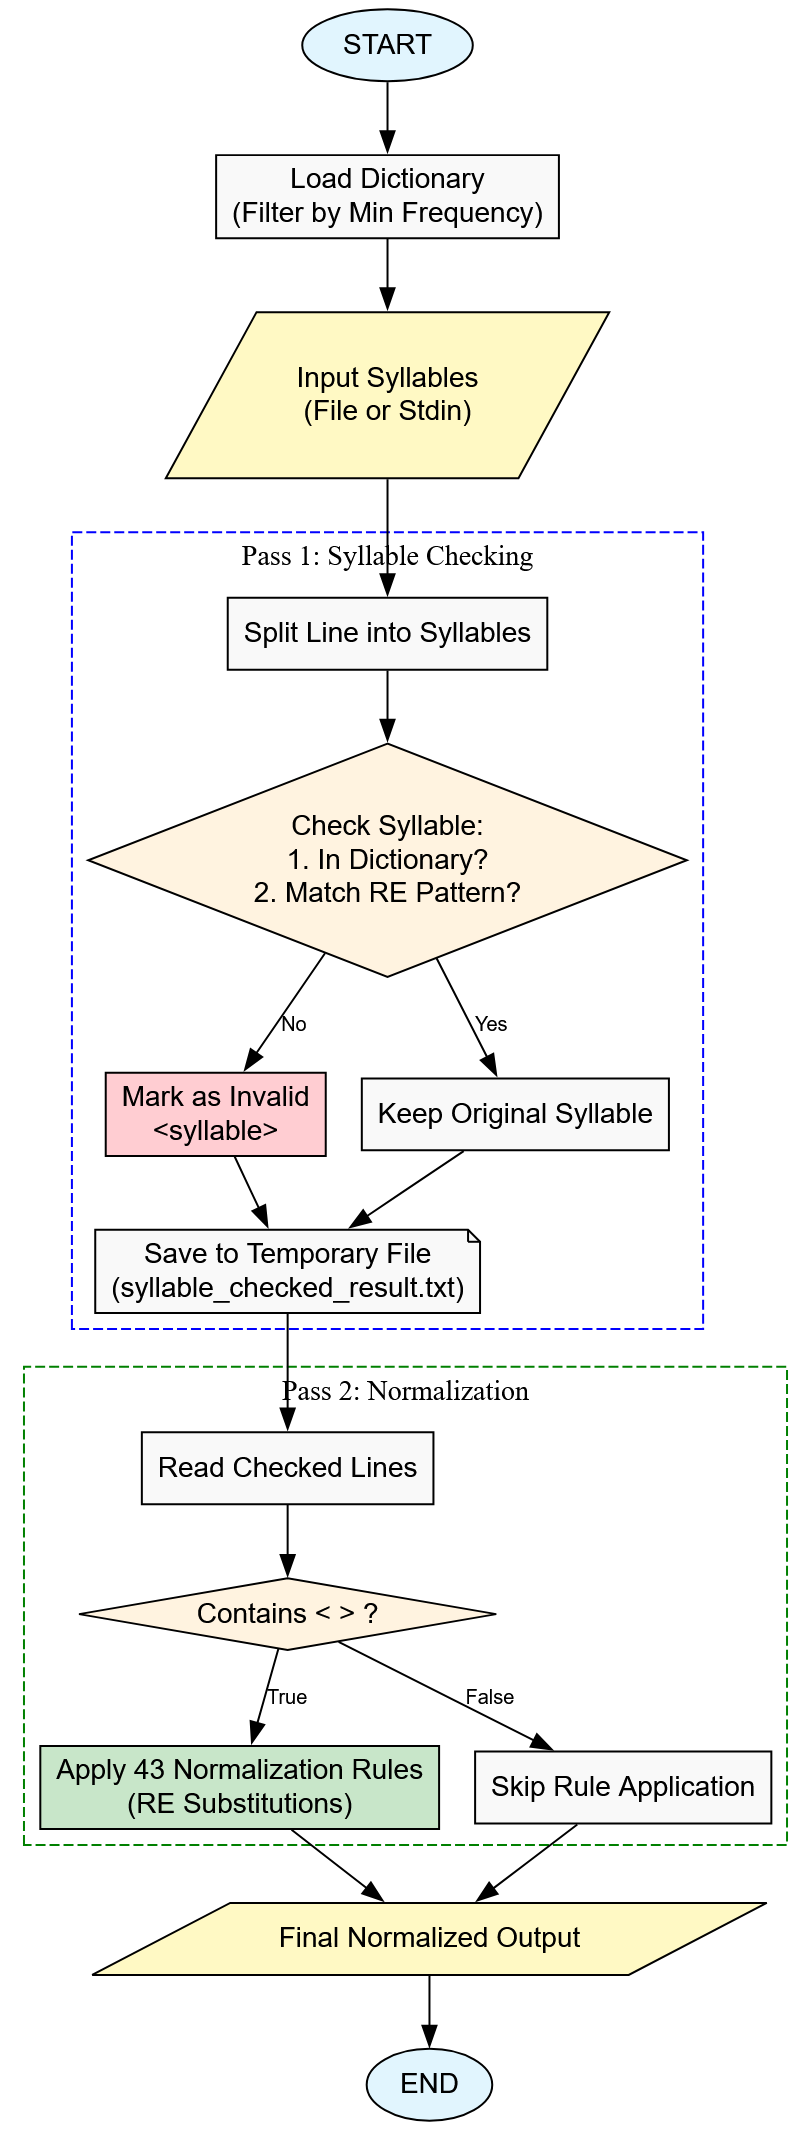

In [36]:
from IPython import display
display.Image("/home/ye/exp/SMT-NMT_tutorial/syl_normalizer/syl_normalizer.png", width=300)

အထက်က တုန်းက သုံးပြခဲ့တာက 2024 တုန်းက ဗားရှင်းပါ။ 
Notebook 2, 3 မှာက updated လုပ်ထားတဲ့ syl_normalization.py ကို သုံးထားပါတယ်။ GitHub မှာလည်း updated လုပ်ထားတဲ့ ဗားရှင်းကိုပဲ တင်ပေးထားလိုက်ပါမယ်။  
### Let's clean training, development and test dataset of Myanmar language

In [57]:
%cd /home/ye/exp/SMT-NMT_tutorial/syl_normalizer

/home/ye/exp/SMT-NMT_tutorial/syl_normalizer


In [59]:
!python ./syl_normalizer.py --help

usage: syl_normalizer.py [-h] [--input INPUT] [--output OUTPUT] [--verbose]
                         [--dictionary DICTIONARY] [--frequency FREQUENCY]
                         [--check {dictionary,RE_and_dictionary}]

Check Burmese syllable structure and normalize text.

options:
  -h, --help            show this help message and exit
  --input INPUT, -i INPUT
                        Input file containing syllables, or use stdin.
  --output OUTPUT, -o OUTPUT
                        Output file to save the results.
  --verbose, -v         Verbose mode: print line number, original syllable,
                        and result.
  --dictionary DICTIONARY, -d DICTIONARY
                        Syllable dictionary filename.
  --frequency FREQUENCY, -f FREQUENCY
                        Minimum frequency to consider a syllable correct.
  --check {dictionary,RE_and_dictionary}, -c {dictionary,RE_and_dictionary}
                        Control whether to check syllables using the
                

In [60]:
!python ./syl_normalizer.py --dictionary ./final_syl_dictionary_13Feb2024.sorted.txt \
--frequency 2 --input ../clean-data/normalize/train.my \
--output ../clean-data/normalize/train.my.clean 

In [61]:
!wc ../clean-data/normalize/train.my

  62625  734742 7067941 ../clean-data/normalize/train.my


In [62]:
!wc ../clean-data/normalize/train.my.clean

  62625  734667 7029308 ../clean-data/normalize/train.my.clean


In [63]:
!head ../clean-data/normalize/train.my.clean

အောက် ပါ ရော ဂါ လက္ခ ဏာ တွေ များ ရှိ ရင်
စိတ် ကို အေး အေး ဆေး ဆေး ထား ပါ
နာ တာ ရှည် ရော ဂါ ရယ် လို့ မ ရှိ ပါ ဘူး ဗျ
လက္ခ ဏာ တွေ နဲ့
ပြီး တဲ့ အ ခါ နား ကြပ် ကို တံ တော င့် ဆစ် နား မှာ ထား မှာ မို့ ပါ ရှင်
ပု စွန် တော့ ကျွန် တော် စား တယ်
သို့ ပေ မဲ့ လည်း
ကျွန် တော် ခေါင်း ပေါ် ရေ ခဲ တင် ထား ရ မ လား
ကွန် ပြူ တာ ရောင် ခြည် နဲ့ ထပ် စစ် ဆေး ပါ မယ် နော်
ဒီ ကြား မှာ ခ ဏ လေး ထိုင် စော င့် ပေး လို့ ရ မ လား


In [64]:
!head ../clean-data/normalize/train.my

အောက် ပါ ရော ဂါ လက္ခ ဏာ တွေ များ ရှိ ရင်
စိတ် ကို အေး အေး ဆေး ဆေး ထား ပါ
နာ တာ ရှည် ရော ဂါ ရယ် လို့ မ ရှိ ပါ ဘူး ဗျ
လက္ခ ဏာ တွေ နဲ့
ပြီး တဲ့ အ ခါ နား ကြပ် ကို တံ တော င့် ဆစ် နား မှာ ထား မှာ မို့ ပါ ရှင်
ပု စွန် တော့ ကျွန် တော် စား တယ် 
သို့ ပေ မဲ့ လည်း
ကျွန် တော် ခေါင်း ပေါ် ရေ ခဲ တင် ထား ရ မ လား 
ကွန် ပြူ တာ ရောင် ခြည် နဲ့ ထပ် စစ် ဆေး ပါ မယ် နော်
ဒီ ကြား မှာ ခ ဏ လေး ထိုင် စော င့် ပေး လို့ ရ မ လား


In [65]:
!tail ../clean-data/normalize/train.my.clean

စိတ် မ ပူ ပါ နဲ့ တော့ ရှင်
လက် နဲ့ ခြေ ထောက် တွေ မှာ လှုပ် ရှား မှု လျော့ နည်း သွား ပါ မယ်
အ သုံး ပြု တာ လျော့ ပါ
အ ပူ ရှိ တာ ကြော င့် လည်း ဖြစ် တာ ပေါ့ ခင် ဗျာ
အဲ တာ က ယား တာ လား ဒါ ဆို နှင်း ခူ ဖြစ် တယ်
သွား ကျိုး ရှိ လား
သို့ မ ဟုတ် ဘယ် သူ တွေ များ လာ လို့ ရ သေး လဲ ခင် ဗျာ
နည်း နည်း တော့ စောင်း ကာ တိုက် ပေး ပါ
ဖိ နပ် ချွတ် ပြီး တာ နဲ့ ဒီ မှာ ရပ် ရ မယ် နော် ခင် ဗျာ
အ ခြား ရော ဂါ လက္ခ ဏာ မျိုး ရော ရှိ လား ရှ င့်


In [66]:
!tail ../clean-data/normalize/train.my

စိတ် မ ပူ ပါ နဲ့ တော့ ရှင်
လက် နဲ့ ခြေ ထောက် တွေ မှာ လှုပ် ရှား မှု လျော့ နည်း သွား ပါ မယ် 
အ သုံး ပြု တာ လျော့ ပါ 
အ ပူ ရှိ တာ ကြော င့် လည်း ဖြစ် တာ ပေါ့ ခင် ဗျာ
အဲ တာ က ယား တာ လား  ဒါ ဆို နှင်း ခူ ဖြစ် တယ် 
သွား ကျိုး ရှိ လား
သို့ မ ဟုတ် ဘယ် သူ တွေ များ လာ လို့ ရ သေး လဲ ခင် ဗျာ
နည်း နည်း တော့ စောင်း ကာ တိုက် ပေး ပါ
ဖိ နပ် ချွတ် ပြီး တာ နဲ့ ဒီ မှာ ရပ် ရ မယ် နော် ခင် ဗျာ
အ ခြား ရော ဂါ လက္ခ ဏာ မျိုး ရော ရှိ လား ရှ င့် 


**Development data cleaning ...**

In [67]:
!python ./syl_normalizer.py --dictionary ./final_syl_dictionary_13Feb2024.sorted.txt \
--frequency 2 --input ../clean-data/normalize/dev.my \
--output ../clean-data/normalize/dev.my.clean

In [68]:
!wc ../clean-data/normalize/dev.my

  10000  117884 1133121 ../clean-data/normalize/dev.my


In [70]:
!wc ../clean-data/normalize/dev.my.clean

  10000  117871 1126953 ../clean-data/normalize/dev.my.clean


**Test data cleaning ...**

In [71]:
!python ./syl_normalizer.py --dictionary ./final_syl_dictionary_13Feb2024.sorted.txt \
--frequency 2 --input ../clean-data/normalize/test.my \
--output ../clean-data/normalize/test.my.clean

In [72]:
!wc ../clean-data/normalize/test.my

  8000  93919 901455 ../clean-data/normalize/test.my


In [73]:
!wc ../clean-data/normalize/test.my.clean

  8000  93908 896405 ../clean-data/normalize/test.my.clean


In [141]:
%cd /home/ye/exp/SMT-NMT_tutorial/clean-data/normalize/

/home/ye/exp/SMT-NMT_tutorial/clean-data/normalize


In [143]:
!head ./test.my

ခွဲ မှ ရ မှာ လား 
မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ် 
အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည် 
ဟုတ် ကဲ့  သူ ဖျား ပါ တယ်  သူ သီး သန့် တော့ မ နေ ခဲ့ ဘူး 
မောင် လေး နောက် ဆုံး အ ကြိမ် ဆေး သောက် ခဲ့ တာ ဘယ် ချိန် လဲ
ကိုယ် မှာ ကူး စက် တာ က နေ ဦး နှောက် ထိ ပါ ကူး စက် လာ တယ်
မစ် စ တာ ပ ရာ မို့ ရဲ့ ဆွေ မျိုး ဝင် လာ ဖို့ တစ် ချက် ခေါ် ပေး ပါ ရှင်
အ ချို ကို လျေ့ာ ချ ကြ ည့် လိုက် ပါ
သူ တို့ နဲ့ အ တူ တူ ရှိ နေ တယ် လို့ ပဲ တွေး မိ နေ တယ် ဗျာ 
ဆေး ယူ ပြီး ပြီ ဆို ရင် တော့ အိမ် ပြန် လို့ ရ ပြီ နော် 


In [144]:
!head ./test.my.clean

ခွဲ မှ ရ မှာ လား
မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ်
အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည်
ဟုတ် ကဲ့ သူ ဖျား ပါ တယ် သူ သီး သန့် တော့ မ နေ ခဲ့ ဘူး
မောင် လေး နောက် ဆုံး အ ကြိမ် ဆေး သောက် ခဲ့ တာ ဘယ် ချိန် လဲ
ကိုယ် မှာ ကူး စက် တာ က နေ ဦး နှောက် ထိ ပါ ကူး စက် လာ တယ်
မစ် စ တာ ပ ရာ မို့ ရဲ့ ဆွေ မျိုး ဝင် လာ ဖို့ တစ် ချက် ခေါ် ပေး ပါ ရှင်
အ ချို ကို လျော့ ချ ကြ ည့် လိုက် ပါ
သူ တို့ နဲ့ အ တူ တူ ရှိ နေ တယ် လို့ ပဲ တွေး မိ နေ တယ် ဗျာ
ဆေး ယူ ပြီး ပြီ ဆို ရင် တော့ အိမ် ပြန် လို့ ရ ပြီ နော်


**cleaning လုပ်ထားတဲ့ ဖိုင်တွေကို machine translation လုပ်တဲ့အခါမှာ သုံးဖို့အတွက် ကော်ပီကူး ပြင်ထားကြရအောင်**

In [75]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/syl_normalizer'

In [76]:
%cd ../clean-data/

/home/ye/exp/SMT-NMT_tutorial/clean-data


In [77]:
!cp ./normalize/*.clean .

In [79]:
!tree .

.
├── dev.my.clean
├── normalize
│   ├── dev.my
│   ├── dev.my.clean
│   ├── dev.th
│   ├── test.my
│   ├── test.my.clean
│   ├── test.th
│   ├── train.my
│   ├── train.my.clean
│   └── train.th
├── test.my.clean
└── train.my.clean

2 directories, 12 files


**.clean တွေကို ဖြုတ်ကြရအောင်**  
SMT မှာက နောက်ဆုံး ဖိုင်နာမည်နောက်ဆုံးပိုင်း (i.e. file extension) က source/target ဘာသာစကားတွေအဖြစ် ယူဆပြီး အလုပ်လုပ်မှာမို့လို့။  

In [80]:
!mv train.my.clean train.my

In [81]:
!mv dev.my.clean dev.my

In [82]:
!mv test.my.clean test.my

In [83]:
!tree .

.
├── dev.my
├── normalize
│   ├── dev.my
│   ├── dev.my.clean
│   ├── dev.th
│   ├── test.my
│   ├── test.my.clean
│   ├── test.th
│   ├── train.my
│   ├── train.my.clean
│   └── train.th
├── test.my
└── train.my

2 directories, 12 files


## Moses SMT Framework

အောက်ပါ လင့်တွေကနေ လေ့လာပါ။ ထဲထဲဝင်ဝင် သိချင်ရင်တော့ user manual မှာ လက်တွေ့ ဘယ်လို run ရမယ် ဆိုတာ အသေးစိတ် ရေးထားတာမို့ ဖတ်ရှုလေ့လာကြပါ။ SMT ထဲက မော်ဒယ်တွေ၊ လက်တွေ့လုပ်ပုံတွေ နားလည်ရင် အလုပ်ထဲမှာ ဖြေရှင်းကြရမယ့် အင်ဂျင်နီယာကိစ္စတွေအတွက် အများကြီး အသုံးဝင်ပါလိမ့်မယ်။   

1. homepage: [https://www2.statmt.org/moses/](https://www2.statmt.org/moses/)
2. User Manual: [http://www2.statmt.org/moses/manual/manual.pdf](http://www2.statmt.org/moses/manual/manual.pdf)

ဆရာက moses framework ရဲ့ executable binary ဖိုင်တွေနဲ့ တခြား လိုအပ်တဲ့ script တွေကို အောက်ပါ path မှာ ပြင်ဆင်ထားပါတယ်။  

In [84]:
!ls /home/ye/tool/mosesbin

ubuntu-17.04  ubuntu-17.04.tgz


In [85]:
%cd /home/ye/tool/mosesbin

/home/ye/tool/mosesbin


moses framework အထဲမှာ ပါဝင်တဲ့ ဖိုင်တွေနဲ့ သူ့ရဲ့ folder structure ကို အကြမ်းဖျဉ်း လေ့လာကြရအောင်။  

In [86]:
%cd ubuntu-17.04/

/home/ye/tool/mosesbin/ubuntu-17.04


In [87]:
!tree .

.
├── moses
│   ├── bin
│   │   ├── 1-1-Extraction
│   │   ├── addLexROtoPT
│   │   ├── biconcor
│   │   ├── build_binary
│   │   ├── config.log
│   │   ├── consolidate
│   │   ├── consolidate-direct
│   │   ├── consolidate-reverse
│   │   ├── CreateOnDiskPt
│   │   ├── CreateProbingPT
│   │   ├── CreateProbingPT2 -> CreateProbingPT
│   │   ├── dump_counts
│   │   ├── evaluator
│   │   ├── extract
│   │   ├── extract-ghkm
│   │   ├── extract-lex
│   │   ├── extract-mixed-syntax
│   │   ├── extractor
│   │   ├── extract-rules
│   │   ├── filter
│   │   ├── filter-rule-table
│   │   ├── fragment
│   │   ├── gcc-6.3.0
│   │   │   └── debug
│   │   │       ├── empty_test_shared
│   │   │       ├── empty_test_shared.o
│   │   │       ├── empty_test_static
│   │   │       └── empty_test_static.o
│   │   ├── generateSequences
│   │   ├── hgdecode
│   │   ├── kbmira
│   │   ├── kenlm_benchmark
│   │   ├── lexical-reordering-score
│   │   ├── lmbrgrid
│   │   ├── lmplz
│   │   ├── merge-sorted


## Phrase Based SMT Tutorial  

YTU မှာ ဆရာ workshop လုပ်တုန်းက တင်ပေးထားခဲ့တဲ့ configuration ဖိုင်စတာတွေက အသုံးဝင်ပါလိမ့်မယ်။   

**MTRSS: Machine Translation Research Summer School**

Here, I uploaded some files that I used at MTRSS (8-10 Oct, 2019),
Yangon Technological University (YTU), Yangon, Myanmar.

Link: [https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt](https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt)  

ဒီကနေ စပြီး လက်တွေ့ PBSMT ကို run ဖို့ စပြင်ပြီး step-by-step လုပ်ပြသွားမယ်။  

In [88]:
%pwd

'/home/ye/tool/mosesbin/ubuntu-17.04'

## Preparing Testset SGM Files 

ခု လက်တွေ့လုပ်ပြမယ့် SMT က moses2 ရဲ့ experimental system ပုံစံမျိုး configuration file ဆောက်ပြီးသွားမှာမို့လို့ SGM ဖိုင်ကို ရှိမရှိ စစ်တယ်။ မတွေ့ရင် run မလုပ်ပေးဘူး။ အဲဒီအတွက် test data တွေကို SGM file format အရင် ပြောင်းကြရအောင်။  

ဆရာပြင်ပေးထားတဲ့ perl script သုံးဖိုင်က အောက်ပါ path အောက်မှာရှိတယ်။ ဒီ Notebook နဲ့ အတူလည်း ရှဲပေးထားပါမယ်။  

[https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data/test-sgm](https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data/test-sgm)  

In [149]:
%cd /home/ye/exp/SMT-NMT_tutorial/clean-data/scripts/

/home/ye/exp/SMT-NMT_tutorial/clean-data/scripts


In [150]:
!cat generate_sgms.pl

#!/usr/bin/perl
use strict;

# written by Ye, NECTEC
# for MTRSS, YTU, Myanmar

my @langs;

#foreach my $trainFile ( </home/ros/experiment/my-rk/data/train.[a-z][a-z]> )
foreach my $trainFile ( <../train.[a-z][a-z]> )
{                        
        $trainFile =~ m/train.([a-z][a-z])/;
        push @langs, $1;
}

foreach my $lang (@langs)
{ 
    `perl ./ref2sgm.pl $lang > test.$lang.ref.sgm`;
    `perl ./src2sgm.pl $lang > test.$lang.src.sgm`;
}


**အထက်က perl script က ပြင်စရာ မလိုပါ။ အောက်က နောက်ထပ် perl script နှစ်ဖိုင်ကိုတော့ ကိုယ်လုပ်မယ့် MT experiment နဲ့ ဆိုင်တဲ့ information ကို ဝင်ရေးပါ။**  

In [151]:
!cat ./src2sgm.pl

#!/usr/bin/perl
use strict;

# written by Ye, NECTEC
# for MTRSS, YTU, Myanmar

my $src = shift;

print "<srcset setid=\"Thai-Myanmar_data\" srclang=\"any\">\n";
print "<doc docid=\"none\" genre=\"8000\" origlang=\"$src\">\n";

#open FILE, "/home/ros/experiment/my-rk/data/test.$src" or die;
open FILE, "../test.$src" or die;

my $id=1;

while( <FILE> )
{
	chomp;
	
	print "<seg id=\"$id\">$_ </seg>\n";
	$id++;
}

print "</doc>\n</srcset>\n";


**နောက်ထပ် တစ်ဖိုင်က reference အတွက်ပါ။** 

In [152]:
!cat ./ref2sgm.pl

#!/usr/bin/perl
use strict;

# written by Ye, NECTEC
# for MTRSS, YTU, Myanmar

my $trg = shift;

#print "<refset trglang=\"$trg\" setid=\"sl_data\" srclang=\"any\">\n";
print "<refset trglang=\"$trg\" setid=\"Thai-Myanmar_data\" srclang=\"any\">\n";
print "<doc sysid=\"ref\" docid=\"none\" genre=\"8000\" origlang=\"any\">\n";

#open FILE, "/home/ros/experiment/my-rk/data/test.$trg" or die;
open FILE, "../test.$trg" or die;
             
my $id=1;

while( <FILE> )
{
	chomp;
	
	print "<seg id=\"$id\">$_ </seg>\n";
	$id++;
}

print "</doc>\n</refset>\n";


### Run perl script  

generate လုပ်ပေးမယ့် perl ကို run လိုက်ရင်အဲဒီ ဖိုလ်ဒါ path အောက်မှာပဲ SGM ဖိုင်တွေ ထွက်လာလိမ့်မယ်။  

In [153]:
!perl ./generate_sgms.pl

In [154]:
!ls *sgm

test.my.ref.sgm  test.my.src.sgm  test.th.ref.sgm  test.th.src.sgm


In [155]:
!head test.my.ref.sgm

<refset trglang="my" setid="Thai-Myanmar_data" srclang="any">
<doc sysid="ref" docid="none" genre="8000" origlang="any">
<seg id="1">ခွဲ မှ ရ မှာ လား </seg>
<seg id="2">မျက် ခံ လှုပ် တဲ့ လက္ခ ဏာ ရှိ မယ် </seg>
<seg id="3">အ ရက် ကို စွ န့် လွှတ် ရ မည် ဖြစ် ပြီး ပ ရို တင်း နှ င့် ဗီ တာ မင် ဓာတ် ကြွယ် ဝ သော အာ ဟာ ရ ရှိ သော အ စား အ စာ များ ကို စား သ င့် သည် </seg>
<seg id="4">ဟုတ် ကဲ့ သူ ဖျား ပါ တယ် သူ သီး သန့် တော့ မ နေ ခဲ့ ဘူး </seg>
<seg id="5">မောင် လေး နောက် ဆုံး အ ကြိမ် ဆေး သောက် ခဲ့ တာ ဘယ် ချိန် လဲ </seg>
<seg id="6">ကိုယ် မှာ ကူး စက် တာ က နေ ဦး နှောက် ထိ ပါ ကူး စက် လာ တယ် </seg>
<seg id="7">မစ် စ တာ ပ ရာ မို့ ရဲ့ ဆွေ မျိုး ဝင် လာ ဖို့ တစ် ချက် ခေါ် ပေး ပါ ရှင် </seg>
<seg id="8">အ ချို ကို လျော့ ချ ကြ ည့် လိုက် ပါ </seg>


In [156]:
!head test.th.ref.sgm

<refset trglang="th" setid="Thai-Myanmar_data" srclang="any">
<doc sysid="ref" docid="none" genre="8000" origlang="any">
<seg id="1">ต้อง ผ่าตัด ไหม </seg>
<seg id="2">หนัง ตา กระตุก </seg>
<seg id="3">คุณ ควร งด แอลกอฮอล์ และ รับประทาน อาหาร ที่ มี ประโยชน์ ซึ่ง อุดม ไป ด้วย โปรตีน และ วิตามิน </seg>
<seg id="4">เธอ ป่วย ค่ะ และ เธอ ไม่ ได้ กัก ตัว ค่ะ </seg>
<seg id="5">น้องทาน ยา ครั้ง สุดท้าย เมื่อ ไหร่ คะ </seg>
<seg id="6">แนวโน้ม ที่ ร่างกาย ติด เชื้อ บาดเจ็บ ต่อ สมอง </seg>
<seg id="7">เรียก ญาติ คุณปราโมท เข้า มา ให้ หน่อย ค่ะ </seg>
<seg id="8">ลด ปริมาน ของ หวาน มัน </seg>


In [157]:
%cd /home/ye/exp/SMT-NMT_tutorial

/home/ye/exp/SMT-NMT_tutorial


## GIZA++ Installation  

Alignment လုပ်ပေးမယ့် tool က ကိုယ့်စက်ထဲမှာ မရှိသေးရင် git clone လုပ်ပြီး install လုပ်ပါ။ ပြီးရင် အဲဒီ path ကို config ဖိုင်မှာ ဝင်ဖြည့်ပေးပါ။  


git clone https://github.com/moses-smt/giza-pp လုပ်ပြီး အဲဒီ path အောက်ကို ဝင်ပြီး make all command ကို run ပါ။  
ye@lst-hpc3090:~/tool/giza-pp$ make all
...
...
...
g++  -O3 -W -Wall plain2snt.cpp -o plain2snt.out
g++  -O3 -g -W -Wall snt2cooc.cpp -o snt2cooc.out
make[1]: Leaving directory '/home/ye/tool/giza-pp/GIZA++-v2'
make -C mkcls-v2
make[1]: Entering directory '/home/ye/tool/giza-pp/mkcls-v2'
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c GDAOptimization.cpp -o GDAOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c HCOptimization.cpp -o HCOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c Problem.cpp -o Problem.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c IterOptimization.cpp -o IterOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c ProblemTest.cpp -o ProblemTest.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c RRTOptimization.cpp -o RRTOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c MYOptimization.cpp -o MYOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c SAOptimization.cpp -o SAOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c TAOptimization.cpp -o TAOptimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c Optimization.cpp -o Optimization.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblemTest.cpp -o KategProblemTest.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblemKBC.cpp -o KategProblemKBC.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblemWBC.cpp -o KategProblemWBC.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c KategProblem.cpp -o KategProblem.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c StatVar.cpp -o StatVar.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c general.cpp -o general.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -c mkcls.cpp -o mkcls.o
g++ -Wall -W -DNDEBUG -O3 -funroll-loops -o mkcls GDAOptimization.o HCOptimization.o Problem.o IterOptimization.o ProblemTest.o RRTOptimization.o MYOptimization.o SAOptimization.o TAOptimization.o Optimization.o KategProblemTest.o KategProblemKBC.o KategProblemWBC.o KategProblem.o StatVar.o general.o mkcls.o
make[1]: Leaving directory '/home/ye/tool/giza-pp/mkcls-v2'
ye@lst-hpc3090:~/tool/giza-pp$

**PBSMT ကို ဖိုလ်ဒါ အသစ်တစ်ခုဆောက်ပြီး အဲဒီအောက်မှာပဲ run သွားမယ်။**

In [90]:
!mkdir pbsmt

In [160]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt

/home/ye/exp/SMT-NMT_tutorial/pbsmt


**kc-my.config.baseline** ကို လေ့လာရင်း အဲဒီဖိုင်ကို ထိုင်း-မြန်မာ ဘာသာပြန်ဖို့အတွက် ဝင်ပြင်ကြရအောင်။  

In [106]:
!cat kc-my.config.baseline


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
moses-src-dir = /home/lar/tool/moses/

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
external-bin-dir = /home/lar/tool/giza-pp-master/mkcls-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin

# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box computer
#srilm-dir = /home/ros/tool/srilm-1.7.1/bin/i686-m64

# irstlm
#irstlm-dir = $moses-src-dir/irstlm/bin

# randlm
#randlm-dir = $moses-src-dir/randlm/bin

# kenlm
lmplz = $moses-bin-dir/lmplz

# data
#myrk-data = /home/lar/experiment/my-rk/smt1/t9
#mykc-data = /home/lar/experiment/kachin-myanmar/demo-mykc-smt/4demo/
mykc-data = /home/lar/experime

Original config.baseline ကို ဝင်ပြင်ပါ။ ပြီးရင် အောက်ပါအတိုင်း run ပြီး Thai-Myamar အတွက် config ဖိုင်ကို generate လုပ်ပါ။  

In [161]:
!ls

config.baseline  generate_config.pl  run-baseline.pl  run-pbsmt.sh


**ပြင်ပြီးသွားတဲ့ config.baseline ဖိုင်က အောက်ပါအတိုင်းပါ**

In [162]:
!cat config.baseline


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
#moses-src-dir = /home/lar/tool/moses/
moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
#external-bin-dir = /home/lar/tool/giza-pp-master/mkcls-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin
external-bin-dir = /home/ye/tool/giza-pp/GIZA++-v2


# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box computer
#srilm-dir = /home/ros/tool/srilm-1.7.1/bin/i686-m64

# irstlm
#irstlm-dir = $moses-src-dir/irstlm/bin

# randlm
#randlm-dir = $moses-src-dir/randlm/bin

# kenlm
lmplz = $moses-bin-dir/lmplz

# data
#myrk-data = /home/lar/experiment/my

## Updating generate_config.pl

generate_config.pl ဖိုင်ကို ဝင်ပြင်ရအုံးမယ်။  

In [112]:
!cat generate_config.pl

#!/usr/bin/perl

# Preparing configuration files for PBSMT experiments
# Output: one configuration file for baseline or PBSMT
# *** Before you run this script, you should prepare training, development and test parallel-data in advance!!!

# Written by Finch-san and Ye
# We used this script for running our NAACL paper:
# Ye Kyaw Thu, Andrew Finch and Eiichiro Sumita, 
# "Interlocking Phrases in Phrase-based Statistical Machine Translation",
# In Proceedings of the NAACL-HLT 2016, June 12-17, San Diego, US, pp. 1076-1081.

# Last updated 9 Oct 2019, @Machine Translation Research Summer School, YTU, Myanmar

use strict;

my @langs;

# you have to update the PBSMT experiment path!!!
#my $smtpath = "/home/lar/experiment/kachin-myanmar/demo-mykc-smt";
my $smtpath = "/media/lar/Transcend/student/lecture/mtrss/pbsmt-demo/pbsmt";

# you have to update the data path for running PBSMT experiment!!!

#foreach my $trainFile ( </panfs/panltg2/users/finch/expt/multibtec/corpus/train.[a-z][a-z]> )
#fo

**After updating**

Update လုပ်ပြီးသားဖိုင်က အောက်ပါအတိုင်းပါ။  


In [114]:
!cat generate_config.pl

#!/usr/bin/perl

# Preparing configuration files for PBSMT experiments
# Output: one configuration file for baseline or PBSMT
# *** Before you run this script, you should prepare training, development and test parallel-data in advance!!!

# Written by Finch-san and Ye
# We used this script for running our NAACL paper:
# Ye Kyaw Thu, Andrew Finch and Eiichiro Sumita, 
# "Interlocking Phrases in Phrase-based Statistical Machine Translation",
# In Proceedings of the NAACL-HLT 2016, June 12-17, San Diego, US, pp. 1076-1081.

# Last updated 9 Oct 2019, @Machine Translation Research Summer School, YTU, Myanmar

use strict;

my @langs;

# you have to update the PBSMT experiment path!!!
#my $smtpath = "/home/lar/experiment/kachin-myanmar/demo-mykc-smt";
#my $smtpath = "/media/lar/Transcend/student/lecture/mtrss/pbsmt-demo/pbsmt";
my $smtpath = "/home/ye/exp/SMT-NMT_tutorial/pbsmt";

# you have to update the data path for running PBSMT experiment!!!

#foreach my $trainFile ( </panfs/panltg2/use

**အဓိက ဝင်ပြင်ခဲ့တာက path တွေပါပဲ**
အထက်ပါအတိုင်း ပြင်ဆင်ပြီးသွားရင် configuration ဖိုင်ကို generate လုပ်ပေးမယ့် perl script ကို run ကြရအောင်။  

In [115]:
 !ls

config.baseline        nohup.out	th-my.config.baseline
generate_config.pl     run-baseline.pl
kc-my.config.baseline  run-pbsmt.sh


In [163]:
!perl ./generate_config.pl

In [164]:
!ls

baseline  config.baseline  generate_config.pl  run-baseline.pl	run-pbsmt.sh


In [165]:
!ls -ad */

baseline/


In [170]:
%cd ..

/home/ye/exp/SMT-NMT_tutorial/pbsmt


In [171]:
!tree .

.
├── baseline
│   ├── my-th
│   │   └── config.baseline.my-th
│   └── th-my
│       └── config.baseline.th-my
├── config.baseline
├── generate_config.pl
├── run-baseline.pl
└── run-pbsmt.sh

4 directories, 6 files


In [172]:
%cd baseline/th-my/

/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my


In [173]:
cat ./config.baseline.th-my

# Config file for th-my (baseline)

[GENERAL]
working-dir = /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my
input-extension = th
output-extension = my
pair-extension = th-my


### directories that contain tools and data
# 
# moses
#moses-src-dir = /home/ros/mosesdecoder
#moses-src-dir = /home/lar/tool/moses/
moses-src-dir = /home/ye/tool/mosesbin/ubuntu-17.04/moses

# moses binaries
moses-bin-dir = $moses-src-dir/bin

# moses scripts
moses-script-dir = $moses-src-dir/scripts

# directory where GIZA++/MGIZA programs resides
#external-bin-dir = /home/lar/tool/giza-pp-master/mkcls-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/GIZA++-v2
#external-bin-dir = /home/lar/tool/giza-pp-master/
#external-bin-dir = /home/ye/tool/mgiza/mgizapp/bin
external-bin-dir = /home/ye/tool/giza-pp/GIZA++-v2


# srilm
#srilm-dir = /data/lttools/training/srilm/srilm-1.6.0/bin/i686-m64
#I haven't installed SRILM yet on Deep Learning Box computer
#srilm-dir = /home/ros/tool/srilm-1.7.1/bin/i686-m64

# i

## show updated perl

## Let's DO SMT

In [176]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt'

In [178]:
!time perl ./run-baseline.pl

my-th-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/config.baseline.my-th
th-my-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/config.baseline.th-my

real	0m0.024s
user	0m0.019s
sys	0m0.006s


## ERROR

In [179]:
!cat ./run1.log

sh: 1: /home/lar/tool/moses/scripts/ems/experiment.perl: not found
sh: 1: /home/lar/tool/moses/scripts/ems/experiment.perl: not found
sh: 1: /home/lar/tool/moses/scripts/ems/experiment.perl: not found
sh: 1: /home/lar/tool/moses/scripts/ems/experiment.perl: not found


## Found Error

run-baseline.pl

        chomp $config;

        my @toks = split /\./, $config;
        my $jobName = "$toks[$#toks]-$toks[$#toks - 1]";

        print "$jobName $config\n";

        `/home/lar/tool/moses/scripts/ems/experiment.perl -config $config -exec -no-graph 2>&1 | tee -a >
        #`/home/ros/mosesdecoder/scripts/ems/experiment.perl -config $config -exec -no-graph`;


## Run Again  

In [180]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt'

In [181]:
!time perl ./run-baseline.pl

my-th-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/config.baseline.my-th
th-my-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/config.baseline.th-my

real	0m0.139s
user	0m0.106s
sys	0m0.026s


## We Forgot!

In [184]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt

/home/ye/exp/SMT-NMT_tutorial/pbsmt


In [186]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial/pbsmt'

In [185]:
!perl ./generate_configs.pl

Can't open perl script "./generate_configs.pl": No such file or directory


In [187]:
!time perl ./run-baseline.pl

my-th-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/config.baseline.my-th
th-my-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/config.baseline.th-my

real	0m0.107s
user	0m0.083s
sys	0m0.028s


## One More Error Example

In [188]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/steps/1

/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/steps/1


In [189]:
!cat TRAINING_prepare-data.1.STDERR

Using SCRIPTS_ROOTDIR: /home/ye/tool/mosesbin/ubuntu-17.04/moses/scripts
Using single-thread GIZA
using pigz 
(1) preparing corpus @ Sun Apr 26 15:46:43 +07 2026
Executing: mkdir -p /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/training/prepared.1
(1.0) selecting factors @ Sun Apr 26 15:46:43 +07 2026
(1.1) running mkcls  @ Sun Apr 26 15:46:43 +07 2026
/home/ye/tool/giza-pp/GIZA++-v2/mkcls -c50 -n2 -p/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/training/corpus.1.th -V/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/training/prepared.1/th.vcb.classes opt
(1.2) creating vcb file /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/training/prepared.1/th.vcb @ Sun Apr 26 15:46:43 +07 2026
Executing: /home/ye/tool/giza-pp/GIZA++-v2/mkcls -c50 -n2 -p/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/training/corpus.1.th -V/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/training/prepared.1/th.vcb.classes opt
(1.1) running mkcls  @ Sun Apr 26 15:46:43 +07 2026
/home/ye/tool/giza

## To Add graph1.png 

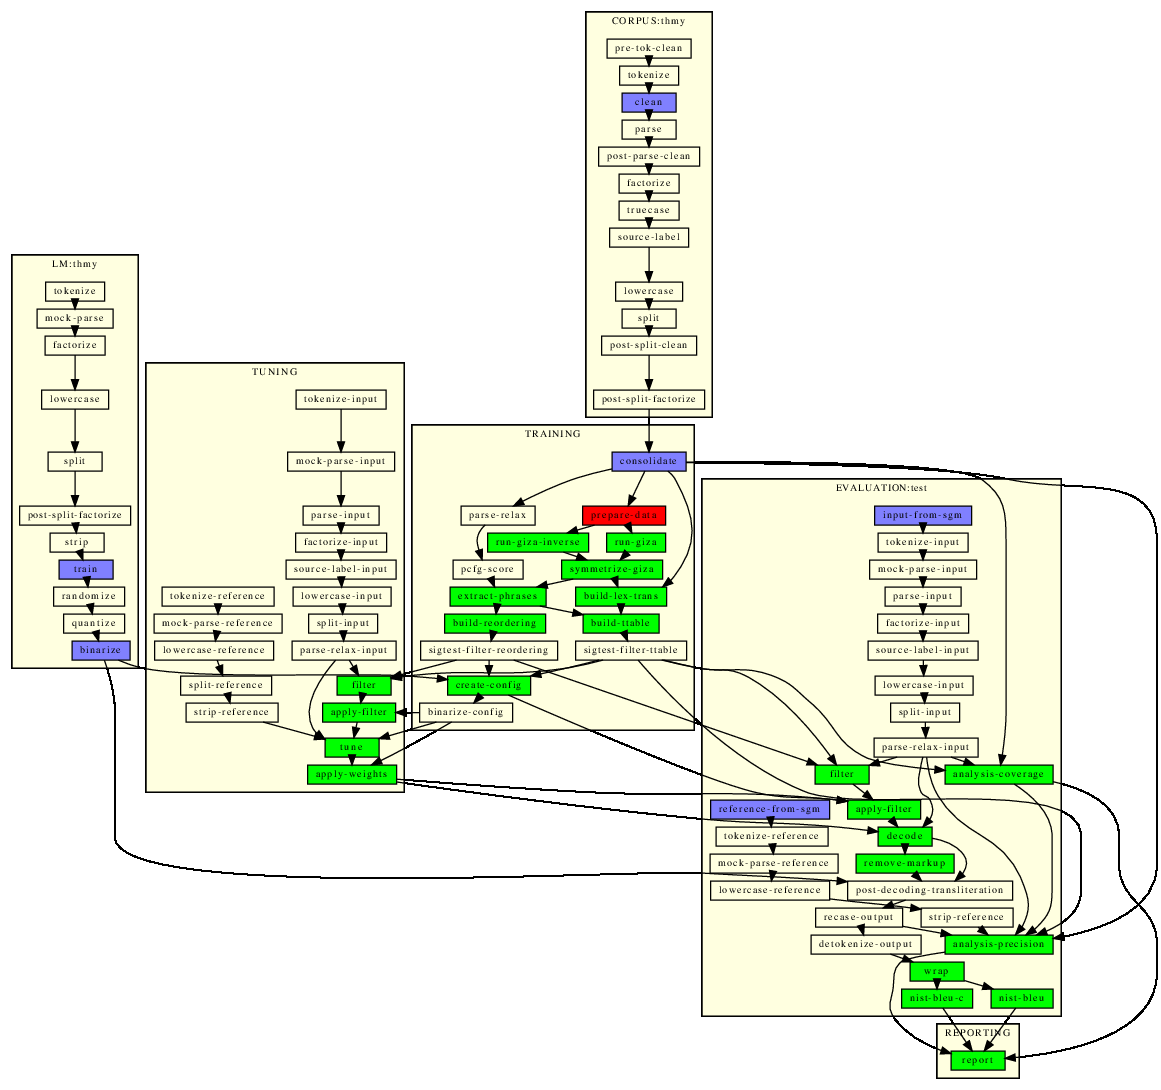

In [1]:
from IPython.display import Image
Image(filename='/home/ye/exp/SMT-NMT_tutorial/error-examples/GIZA-error.png', width=800)

## Solution

အထက်ပါ error ကိုတော့ အတွေ့အကြုံအရ သိနေတာမို့ mkcls binary ဖိုင်ကို GIZA++-v2/ ဖိုလ်ဒါအောက်ကို ကော်ပီကူးထည့်ပေးလိုက်ယုံနဲ့ ပြေလည်ပါတယ်။ အောက်ပါအတိုင်းပါ။  

ye@lst-hpc3090:~/tool/giza-pp$ cp ./mkcls-v2/mkcls ./GIZA++-v2/  

## ERROR

တချို့ error တွေက terminal မှာ ဘာမှမပြပဲ ရပ်သွားတာမျိုးလည်း ဖြစ်တတ်ပါတယ်။ အဲဒါဆိုရင် အများသောအားဖြင့် perl script မှာ path ပေးတာ လွဲသွားလို့ပါ။  

ဘာဖိုင်မှ ထွက်မလာတာကို တမင်တကာ လုပ်ပြထားတာပါ။   
config နဲ့ SMT ကို run မယ်ဆိုရင် နောက်ထပ် ပြင်ရမယ့် အဆင့် ရှိသေးတယ်။ အဲဒါက ဒေတာဖိုလ်ဒါအောက်မှာ ဝင်လုပ်ရမယ်။  

Refer following link:  
[https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data](https://github.com/ye-kyaw-thu/MTRSS/tree/master/pbsmt/data)  

ဒီတစ်ခေါက် tutorial အတွက်တော့ SMT-NMT_tutorial/pbsmt/ ဖိုလ်ဒါအောက်မှာလည်း ကောပီကူးထည့်ပေးထားမယ်။  
အဲဒီ script ကို ကိုယ့် စက်ထဲက parallel data ဒေတာ ဖိုလ်ဒါအောက်ကို ကောပီကူးယူပြီး ပြင်ဆင်ကြပါ။  

In [125]:
%cd ../../

/home/ye/exp/SMT-NMT_tutorial


In [127]:
!ls ./scripts

generate_sgms.pl  ref2sgm.pl  src2sgm.pl


In [128]:
cp -r scripts/ ./clean-data/

path ပြင်ပြီးသား update လုပ်ပြီးသား perl script တွေနဲ့ run ကြရလိမ့်မယ်။ ဥပမာ အောက်ပါအတိုင်း  

In [131]:
%cd /home/ye/exp/SMT-NMT_tutorial/clean-data/

/home/ye/exp/SMT-NMT_tutorial/clean-data


In [132]:
%cd scripts/

/home/ye/exp/SMT-NMT_tutorial/clean-data/scripts


In [134]:
!tree .

.
├── generate_sgms.pl
├── ref2sgm.pl
└── src2sgm.pl

1 directory, 3 files


In [135]:
!perl ./generate_sgms.pl

sh: 1: ./ref2sgm.pl: Permission denied
sh: 1: ./src2sgm.pl: Permission denied


**run-pbsmt.sh ကို Executable ဖြစ်အောင် permission ပေးကြရအောင်...**

In [109]:
!chmod +x ./run-pbsmt.sh

In [110]:
!cat run-pbsmt.sh

#!/bin/bash

# Written by Ye, NICT, Kyoto, Japan
# How to run: time bash ./run-pbsmt.sh 

# after running this script, you will get baseline/ folder 
perl ./generate_configs.pl

# start running PBSMT
nohup time perl ./run-baseline.pl
#perl ./run-baseline.pl


**Shell script ကို run မယ်**

In [111]:
!./run-pbsmt.sh

Can't open perl script "./generate_configs.pl": No such file or directory
nohup: ignoring input and appending output to 'nohup.out'


## Notes

ဒီ notebook မှာ ကြုံခဲ့ရသလိုပါပဲ error အများစုက path လွဲတာ၊ config ဖိုင်မှာ တခုခု update လုပ်ဖို့ ကျန်တာ၊ test data တွေကို SGM format ပြောင်းဖို့ မေ့ကျန်ခဲ့တာ၊ GIZA++ ရဲ့ mkcls ကို ရှာမတွေ့တာ တွေပါပဲ။ အဲဒီလိုမျိုး error မှ မဟုတ်ရင်တော့ ဒေတာနဲ့ ဆိုင်ပါလိမ့်မယ်။ Parallel corpus မှာ တချို့ blank line တွေ ပါနေတာတို့ special character တွေကို ရှင်းဖို့ လိုနေသေးတာတို့ ဖြစ်ဖို့ များပါတယ်။  

Error အကုန် ရှင်းပြီးရင်တော့ run လိုက်ရင် အစအဆုံး ပြီးအောင် run ပေးသွားပါလိမ့်မယ်။  

## PBSMT Experiment 

In [2]:
%pwd

'/home/ye/exp/SMT-NMT_tutorial'

In [3]:
%cd ./pbsmt/

/home/ye/exp/SMT-NMT_tutorial/pbsmt


In [4]:
!ls *

config.baseline      nohup.out	run-baseline.pl
generate_configs.pl  run1.log	run-pbsmt.sh


In [5]:
!perl ./generate_configs.pl

In [7]:
!ls * --color=auto

config.baseline      nohup.out  run-baseline.pl
generate_configs.pl  run1.log   run-pbsmt.sh

baseline:
my-th  th-my


In [8]:
!tree ./baseline

./baseline
├── my-th
│   └── config.baseline.my-th
└── th-my
    └── config.baseline.th-my

3 directories, 2 files


In [9]:
!time perl run-baseline.pl

my-th-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/config.baseline.my-th
th-my-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/config.baseline.th-my

real	20m7.036s
user	0m8.171s
sys	0m3.211s


Training data က စာကြောင်းရေ ၅၀၀၀ ကျော်၊ development data က စာကြောင်းရေ ၅၀၀ ကျော်နဲ့ test data က စာကြောင်းရေ ၁၀၀ နဲ့ပဲ run တာမို့လို့ မြန်မာ-ထိုင်း၊ ထိုင်း-မြန်မာ အတွက်က ဆာဗာပေါ်မှာ မိနစ် ၂၀ကျော်ပဲ ကြာပါတယ်။  

System တစ်ခုလုံး run သွားတဲ့ ဂရဖ်တွေကို ကြည့်ကြည့်ရအောင်။  

အောက်ပါ ဂရဖ်က မြန်မာ-ထိုင်း အတွက်ပါ။  

In [10]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/steps/1

/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/steps/1


In [11]:
!ls *

config.1
CORPUS_thmy_clean.1
CORPUS_thmy_clean.1.DONE
CORPUS_thmy_clean.1.INFO
CORPUS_thmy_clean.1.STDERR
CORPUS_thmy_clean.1.STDERR.digest
CORPUS_thmy_clean.1.STDOUT
EVALUATION_test_analysis-coverage.1
EVALUATION_test_analysis-coverage.1.DONE
EVALUATION_test_analysis-coverage.1.INFO
EVALUATION_test_analysis-coverage.1.STDERR
EVALUATION_test_analysis-coverage.1.STDERR.digest
EVALUATION_test_analysis-coverage.1.STDOUT
EVALUATION_test_analysis-precision.1
EVALUATION_test_analysis-precision.1.DONE
EVALUATION_test_analysis-precision.1.INFO
EVALUATION_test_analysis-precision.1.STDERR
EVALUATION_test_analysis-precision.1.STDERR.digest
EVALUATION_test_analysis-precision.1.STDOUT
EVALUATION_test_apply-filter.1
EVALUATION_test_apply-filter.1.DONE
EVALUATION_test_apply-filter.1.INFO
EVALUATION_test_apply-filter.1.STDERR
EVALUATION_test_apply-filter.1.STDERR.digest
EVALUATION_test_apply-filter.1.STDOUT
EVALUATION_test_decode.1
EVALUATION_test_decode.1.DONE
EVALUATION_test_decode.1.INFO
EVALUATION

In [12]:
!ls *.png

graph.1.png


graph.1.png ကိုပဲ quality ကောင်းအောင် ပုံပြင်ထုတ်ထားပြီး error-examples/ ဖိုလ်ဒါအောက်ထဲမှာပဲ သိမ်းထားပေးလိုက်ပါတယ်။  

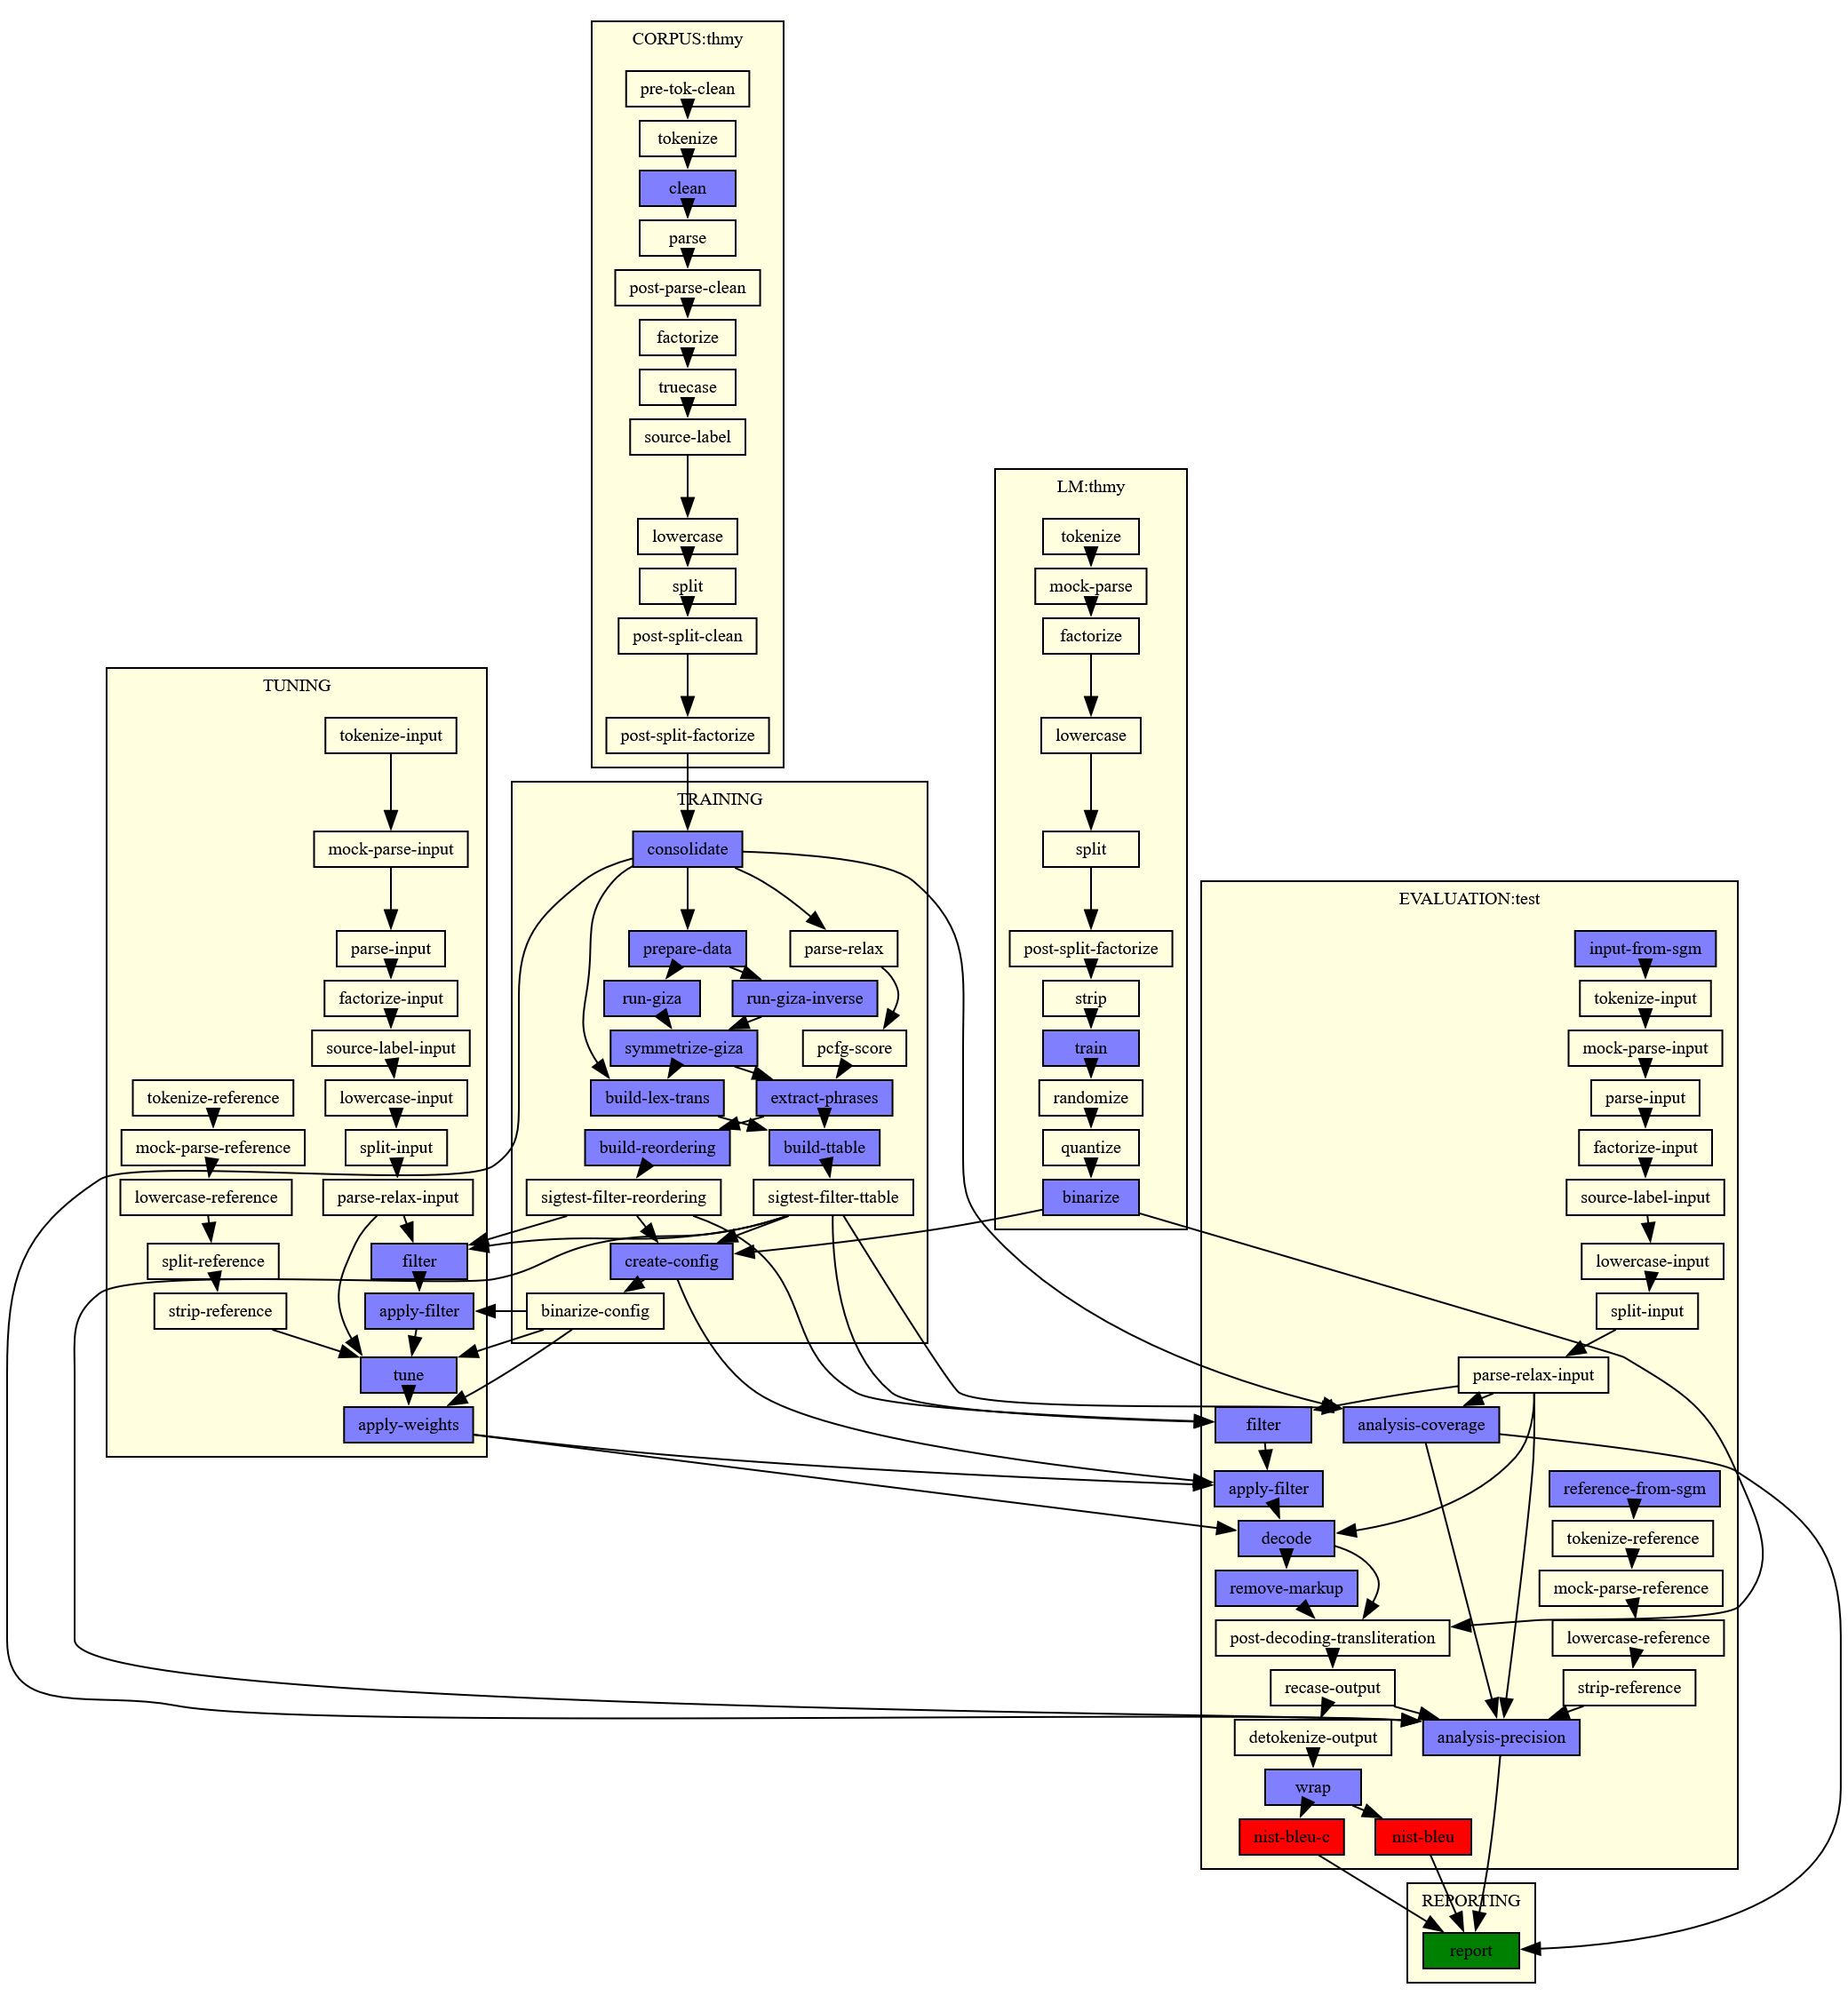

In [13]:
from IPython.display import Image
Image(filename='/home/ye/exp/SMT-NMT_tutorial/error-examples/graph.1.my-th.png', width=800)

အောက်ဆုံးပိုင်းမှာ အနီနဲ့ nist-bleu score နဲ့ ပတ်သက်ပြီး ပြနေပေမဲ့ စိုးရိမ်စရာ မရှိပါဘူး။ 
ဒါပေမဲ့ multi-bleu နဲ့ တွက်ထားတာကိုတော့ ဆရာတို့ လိုချင်တယ်။ အဲဒါက ပါမလာဘူး။ 
config ဖိုင်ထဲမှာ assign မလုပ်ထားလို့ ပေးနေတဲ့ error လို့ ထင်ပါတယ်။ 

Config ဖိုင် template ကို ဝင်ကြည့်တော့ အောက်ပါအတိုင်း comment ပိတ်ထားတာကို တွေ့ရတယ်။
သေချာတယ်။ ကျောင်းသားတွေကို ကိုယ်ဖာသာကိုယ် ရှာတွက်တတ်ဖို့ exercise လုပ်ဖို့ ပိတ်ထားခဲ့တာ။  

```
### BLEU
#
nist-bleu = $moses-script-dir/generic/mteval-v13a.pl
nist-bleu-c = "$moses-script-dir/generic/mteval-v13a.pl -c"
#multi-bleu = $moses-script-dir/generic/multi-bleu.perl
#ibm-bleu =
```

အထက်က multi-bleu လိုင်းကိုပါ ဖွင့်ပေးပြီး နောက်တစ်ခေါက် ထပ် run ကြည့်ရအောင်။  

In [17]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt

/home/ye/exp/SMT-NMT_tutorial/pbsmt


In [18]:
%rm -r baseline/

In [20]:
!perl ./generate_configs.pl

In [22]:
!tree ./baseline

./baseline
├── my-th
│   └── config.baseline.my-th
└── th-my
    └── config.baseline.th-my

3 directories, 2 files


config ဖိုင်ကို ပြင်ပြီး နောက်တစ်ခေါက် ထပ် run မယ်။  

In [23]:
!time perl ./run-baseline.pl

my-th-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/config.baseline.my-th
th-my-baseline /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/config.baseline.th-my

real	11m10.345s
user	0m8.018s
sys	0m2.715s


test-run လုပ်ထားတဲ့ my-th ရလဒ်ကို ဝင်လေ့လာရအောင်။  

In [24]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/evaluation

/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/my-th/evaluation


In [25]:
!ls * --color=auto

test.cleaned.1          test.input.txt.1   test.nist-bleu-c.1
test.detokenized.sgm.1  test.multi-bleu.1  test.output.1
test.filtered.ini.1     test.nist-bleu.1   test.output.1.wa

test.analysis.1:
bleu-annotation            n-gram-recall.3
corpus-coverage-by-phrase  n-gram-recall.4
corpus-coverage-summary    precision-by-corpus-coverage
corpus-unknown             precision-by-input-word
input-annotation           precision-by-ttable-coverage
n-gram-precision.1         segmentation
n-gram-precision.2         segmentation-annotation
n-gram-precision.3         summary
n-gram-precision.4         ttable-coverage-by-phrase
n-gram-recall.1            ttable-coverage-summary
n-gram-recall.2            ttable-unknown

test.filtered.1:
info           phrase-table.0-0.1.1.gz
input.4083555  reordering-table.1.wbe-msd-bidirectional-fe.0-0.1
moses.ini


In [26]:
!cat test.multi-bleu.1

BLEU = 6.19, 30.7/9.0/3.3/1.6 (BP=1.000, ratio=1.220, hyp_len=858, ref_len=703)


BLEU score က test-run လုပ်ထားတာမို့ တအားနည်းပါတယ်။ SMT pipeline အစအဆုံး ပြီးမပြီး confirm လုပ်ရအောင်။  

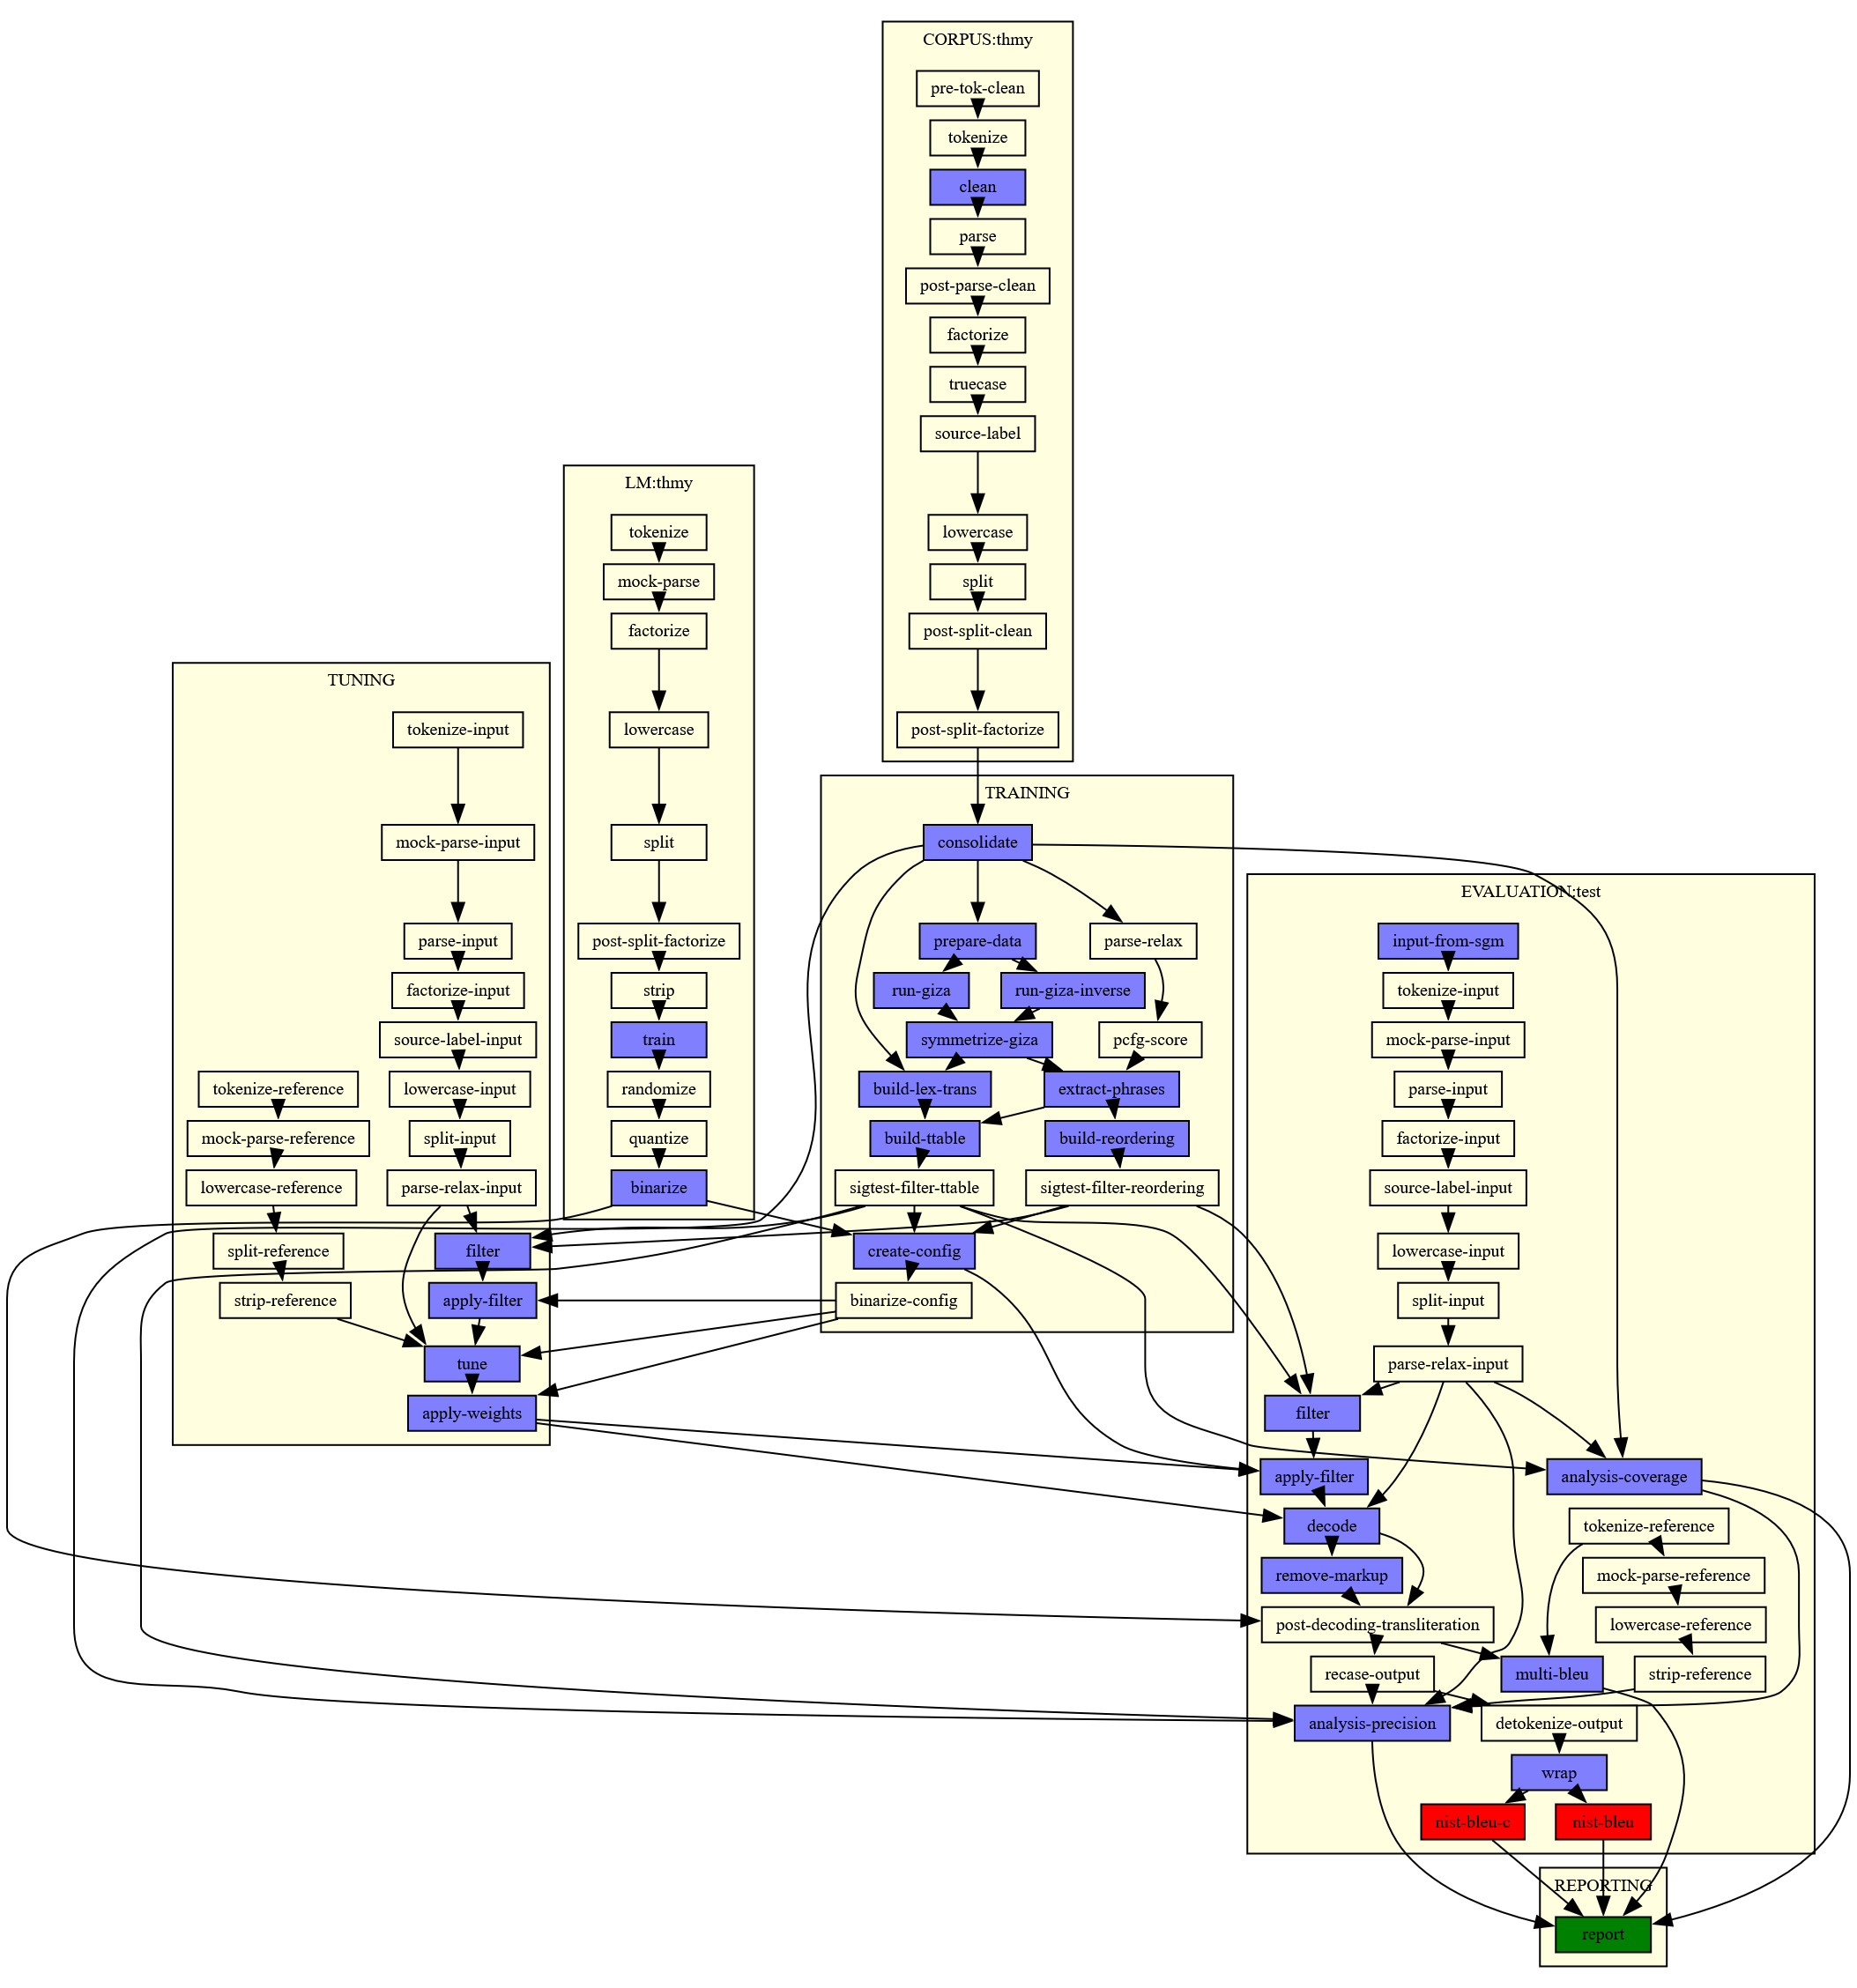

In [28]:
from IPython.display import Image
Image(filename='/home/ye/exp/SMT-NMT_tutorial/error-examples/graph.1.my-th-2ndtime.png', width=800)

အောက်ဆုံးပိုင်းမှာ multi-bleu ပါလာတာကို တွေ့ရပါပြီ။ အဲဒါကြောင့် BLEU score တွက်ပေးထားတာကို မြင်ရတာပါ။ ကောင်းပြီ။ ထိုင်း-မြန်မာ ဘက်ရဲ့ ရလဒ်ကို ဝင်ကြည့်ရအောင်။  

In [29]:
%cd /home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/evaluation

/home/ye/exp/SMT-NMT_tutorial/pbsmt/baseline/th-my/evaluation


In [30]:
!cat ./test.multi-bleu.1

BLEU = 11.77, 40.4/18.3/8.2/3.8 (BP=0.955, ratio=0.956, hyp_len=1163, ref_len=1216)


ထိုင်း-မြန်မာ ရလဒ်ကတော့ အထက်ပါအတိုင်းပါပဲ။ 11.77 ရရှိပါတယ်။  
test-run အစအဆုံး ပြီးပါပြီ။  

ခုလောက်ဆိုရင် SMT running pipeline တော့ အကြမ်း နားလည်ပြီလို့ ယူဆပါတယ်။  
နောက်ထပ် Jupyter notebook နှစ်ခုမှာတော့ လက်ရှိ ထိုင်းဘက်က Lab မှာ ပြင်ဆင်နေဆဲဖြစ်တဲ့ မြန်မာ-ထိုင်း medical domain parallel corpus အကုန်ကို သုံးပြီး SMT ထပ် run ပါမယ်။ 